In [1]:
import torch
from datasets import load_dataset
dataset = load_dataset("bentrevett/multi30k")


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [5]:
type(dataset)

datasets.dataset_dict.DatasetDict

In [8]:
len(dataset['train'])

29000

In [13]:
sample = dataset['train'][0]
sample

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

In [15]:
def tokenize(lines):
    
    return [line.split() for line in lines]


lines = tokenize(dataset['train']['en'])
print(len(lines))
print(lines[0])



29000
['Two', 'young,', 'White', 'males', 'are', 'outside', 'near', 'many', 'bushes.']


In [ ]:
import re
class EnglishTokenizer:
    """英语分词器"""
    def __init__(self, lowercase: bool = False):
        self.lowercase = lowercase
        self.pattern = re.compile(
            r"[a-zA-Z]+(?:'[a-zA-Z]+)?" r"|\d+(?:\.\d+)?" r"|\.\.\.|--" r"|[^\w\s]"
        )

    def _tokenize(self, text: str) -> list[str]:
        if self.lowercase:
            text = text.lower()
        return self.pattern.findall(text)

    def __call__(self, text):
        # 如果传入的是字符串，直接处理
        if isinstance(text, str):
            return self._tokenize(text)
        # 如果传入的是列表/列（例如批处理），批量分词
        return [self._tokenize(t) for t in text]


class GermanTgtTokenizer:
    """专门处理目标语言 (German) 的分词器"""

    def __init__(self, lowercase: bool = False):
        # 德语名词首字母需大写，默认 lowercase=False 以保留名词语法特征
        self.lowercase = lowercase

        self.pattern = re.compile(
            r"[a-zA-ZäöüßÄÖÜ]+(?:'[a-zA-ZäöüßÄÖÜ]+)?"
            r"|\d+(?:[.,]\d+)?"
            r"|\.\.\.|--"
            r"|[„“»«\"']"
            r"|[^\w\s]",
            re.UNICODE,
        )

    def _tokenize(self, text: str) -> list[str]:
        if self.lowercase:
            text = text.lower()
        return self.pattern.findall(text)
    
    def __call__(self, text):
        # 如果传入的是字符串，直接处理
        if isinstance(text, str):
            return self._tokenize(text)
        # 如果传入的是列表/列（例如批处理），批量分词
        return [self._tokenize(t) for t in text]

src_tokenizer = EnglishTokenizer(lowercase=True)
tgt_tokenizer = GermanTgtTokenizer(lowercase=True)
tokenized_src_data = src_tokenizer(dataset['train']['en'])
print(tokenized_src_data[0])
tokenized_tgt_data = tgt_tokenizer(dataset['train']['de'])
print(tokenized_tgt_data[0])

['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
['zwei', 'junge', 'weiße', 'männer', 'sind', 'im', 'freien', 'in', 'der', 'nähe', 'vieler', 'büsche', '.']


In [ ]:
from pyparsing import tokenMap


class Tokenizer:
    def __init__(self,lang):
        if lang == 'en':
            self.lowercase = True
            self.pattern = re.compile(
                        r"[a-zA-Z]+(?:'[a-zA-Z]+)?" r"|\d+(?:\.\d+)?" r"|\.\.\.|--" r"|[^\w\s]"
                    )
        elif lang == 'de':
             self.lowercase = False
             self.pattern = re.compile(
                        r"[a-zA-ZäöüßÄÖÜ]+(?:'[a-zA-ZäöüßÄÖÜ]+)?"
                        r"|\d+(?:[.,]\d+)?"
                        r"|\.\.\.|--"
                        r"|[„“»«\"']"
                        r"|[^\w\s]",
                        re.UNICODE,
                    )

    def _tokenize(self, text: str) -> list[str]:
        if self.lowercase:
            text = text.lower()
        return self.pattern.findall(text)

    def __call__(self, text):
        if isinstance(text, str):
            return self._tokenize(text)
        return [self._tokenize(t) for t in text]        

tokenizer_en = Tokenizer('en')
tokenizer_de = Tokenizer('de')

print(tokenizer_en(dataset['train']['en'])[0])
print(tokenizer_de(dataset['train']['de'])[0])

['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
['Zwei', 'junge', 'weiße', 'Männer', 'sind', 'im', 'Freien', 'in', 'der', 'Nähe', 'vieler', 'Büsche', '.']


In [29]:
dataset['test']['en'][0],dataset['test']['de'][0]


('A man in an orange hat starring at something.',
 'Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.')

In [30]:
from collections import Counter

class Vocab:
    """给文本建立字典."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=['<eos>','<bos>','<padding>']):
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(
            sorted(
                set(
                    ["<unk>"]
                    + reserved_tokens
                    + [token for token, freq in self.token_freqs if freq >= min_freq]
                )
            )
        )
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

In [31]:
src_tokens = tokenizer_en(dataset['train']['en'])
tgt_tokens = tokenizer_de(dataset['train']['de'])

en_vocab = Vocab(src_tokens,2)
tgt_vocab = Vocab(tgt_tokens)

len(en_vocab),len(tgt_vocab)


(5955, 18494)

In [38]:
en_vocab.token_to_idx

{'!': 0,
 '"': 1,
 '#': 2,
 '%': 3,
 '&': 4,
 "'": 5,
 '(': 6,
 ')': 7,
 ',': 8,
 '-': 9,
 '.': 10,
 '000': 11,
 '1': 12,
 '10': 13,
 '100': 14,
 '11': 15,
 '12': 16,
 '13': 17,
 '14': 18,
 '1950': 19,
 '2': 20,
 '2008': 21,
 '2012': 22,
 '24': 23,
 '25': 24,
 '3': 25,
 '30': 26,
 '38': 27,
 '4': 28,
 '40': 29,
 '5': 30,
 '50': 31,
 '6': 32,
 '63': 33,
 '7': 34,
 '8': 35,
 '80': 36,
 '9': 37,
 '96': 38,
 ':': 39,
 ';': 40,
 '<bos>': 41,
 '<eos>': 42,
 '<padding>': 43,
 '<unk>': 44,
 '?': 45,
 '`': 46,
 'a': 47,
 'abandoned': 48,
 'aboard': 49,
 'about': 50,
 'above': 51,
 'abs': 52,
 'accepting': 53,
 'accident': 54,
 'accompanied': 55,
 'accompanies': 56,
 'accompaniment': 57,
 'accordion': 58,
 'acoustic': 59,
 'acrobat': 60,
 'acrobatic': 61,
 'acrobatics': 62,
 'across': 63,
 'act': 64,
 'acting': 65,
 'action': 66,
 'actions': 67,
 'actively': 68,
 'activities': 69,
 'activity': 70,
 'actors': 71,
 'ad': 72,
 'add': 73,
 'adding': 74,
 'addresses': 75,
 'addressing': 76,
 'adds': 

In [41]:
import matplotlib.pyplot as plt
import numpy as np


def show_plt(vocab):
    # 1. 假设 vocab 是已经实例化好的 Vocab 对象
    # 从 vocab.token_freqs 提取词频 (已按降序排列)
    frequencies = [freq for token, freq in vocab.token_freqs]
    ranks = np.arange(1, len(frequencies) + 1)

    # 2. 绘制对比趋势图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 子图 1: 线性坐标轴（长尾分布）
    ax1.plot(ranks, frequencies, color="royalblue", lw=2)
    ax1.set_title("Word Frequency vs. Rank (Linear Scale)")
    ax1.set_xlabel("Rank")
    ax1.set_ylabel("Frequency")
    ax1.grid(True, linestyle="--", alpha=0.6)

    # 子图 2: 双对数坐标轴（齐普夫定律检验）
    ax2.loglog(ranks, frequencies, color="crimson", lw=2, marker=".", markersize=3)
    ax2.set_title("Zipf's Law (Log-Log Scale)")
    ax2.set_xlabel("Rank (log)")
    ax2.set_ylabel("Frequency (log)")
    ax2.grid(True, which="both", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

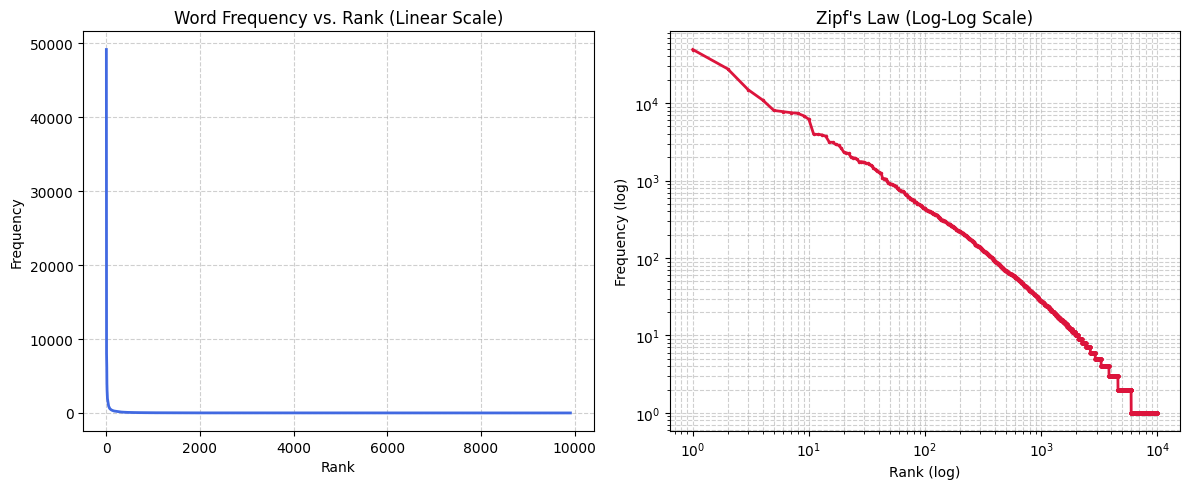

In [42]:
vocab3 = Vocab(src_tokens, min_freq=3)
show_plt(vocab3)